<a href="https://colab.research.google.com/github/Tanvir284/Cirrhosis_Multiclass_classification_with_ML/blob/main/Cirrhosis_Multiclass_classification_with_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

bubt_artificial_intelligence_conquest_2025_path = kagglehub.competition_download('bubt-artificial-intelligence-conquest-2025')
mdtanvirruhit_contest_dataset_path = kagglehub.dataset_download('mdtanvirruhit/contest-dataset')

print('Data source import complete.')


In [ ]:
# Cell 1: Install & imports
import sys, subprocess, pkgutil, os
def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Install required packages if missing
for pkg in ["optuna", "lightgbm", "xgboost", "catboost", "category_encoders", "scipy"]:
    if not pkgutil.find_loader(pkg):
        print("Installing", pkg)
        pip_install(pkg)

# Standard imports
import gc, warnings, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted")

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

import lightgbm as lgb
import xgboost as xgb
import catboost as cat
import optuna
import category_encoders as ce
from scipy.optimize import minimize

RANDOM_STATE = 42
N_FOLDS = 5
print("Libraries loaded. LightGBM:", lgb.__version__, "XGBoost:", xgb.__version__)


Libraries loaded. LightGBM: 4.6.0 XGBoost: 2.0.3


In [ ]:
# Cell 2: Load data (auto-discover typical Kaggle paths)
def find_file(name_hint):
    name_hint = name_hint.lower()
    for root, _, files in os.walk("."):
        for f in files:
            if name_hint in f.lower():
                return os.path.join(root, f)
    if os.path.exists("/kaggle/input"):
        for root, _, files in os.walk("/kaggle/input"):
            for f in files:
                if name_hint in f.lower():
                    return os.path.join(root, f)
    return None

train_path = find_file("train.csv")
test_path = find_file("test.csv")
sample_path = find_file("sample_submission.csv")

print("train:", train_path)
print("test :", test_path)
print("sample:", sample_path)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)

ID_COL = "id"
TARGET = "Status"  # confirmed

print("Shapes -> train:", train.shape, "test:", test.shape, "sample:", sample.shape)
print("Target classes:", sorted(train[TARGET].unique()))


train: /kaggle/input/bubt-artificial-intelligence-conquest-2025/train.csv
test : /kaggle/input/bubt-artificial-intelligence-conquest-2025/test.csv
sample: /kaggle/input/bubt-artificial-intelligence-conquest-2025/sample_submission.csv
Shapes -> train: (15000, 20) test: (10000, 19) sample: (10000, 4)
Target classes: ['C', 'CL', 'D']


,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,859.0,Placebo,17841.0,F,N,Y,N,N,2.1,396.0,3.70,74.0,2148.0,136.74,144.0,298.0,11.0,4.0,D
1,1,1141.0,Placebo,18102.0,F,N,Y,Y,S,2.1,187.0,3.48,4.0,918.0,120.90,90.0,213.0,12.4,2.0,D
2,2,853.0,D-penicillamine,16728.0,F,N,Y,Y,N,5.7,482.0,3.67,161.0,11552.0,136.74,165.0,102.0,11.5,4.0,D
3,3,1785.0,D-penicillamine,19358.0,F,N,Y,N,N,2.1,350.0,3.36,74.0,661.0,272.80,231.0,166.0,11.4,4.0,D
4,4,1418.0,Placebo,22306.0,F,N,Y,Y,S,2.0,426.0,3.74,86.0,13862.4,136.00,114.0,339.0,11.0,4.0,D


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8457 non-null   object 
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  object 
 5   Ascites        8464 non-null   object 
 6   Hepatomegaly   8453 non-null   object 
 7   Spiders        8449 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6623 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8338 non-null   float64
 13  Alk_Phos       8450 non-null   float64
 14  SGOT           8446 non-null   float64
 15  Tryglicerides  6574 non-null   float64
 16  Platelets      14462 non-null  float64
 17  Prothrombin    14981 non-null  float64
 18  Stage 

Status
C     10234
D      4423
CL      343
Name: count, dtype: int64

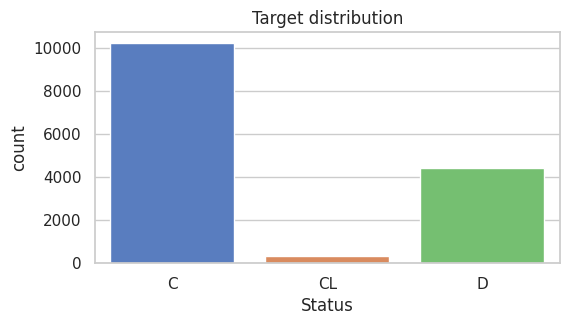


Top missing (train):


Tryglicerides    0.561733
Cholesterol      0.558467
Copper           0.444133
SGOT             0.436933
Spiders          0.436733
Alk_Phos         0.436667
Hepatomegaly     0.436467
Drug             0.436200
Ascites          0.435733
Platelets        0.035867
Prothrombin      0.001267
dtype: float64


Top missing (test):


Tryglicerides    0.5643
Cholesterol      0.5609
Copper           0.4457
Alk_Phos         0.4387
SGOT             0.4387
Spiders          0.4385
Drug             0.4383
Hepatomegaly     0.4380
Ascites          0.4376
Platelets        0.0384
Prothrombin      0.0016
dtype: float64

,count,mean,std,min,25%,50%,75%,max
N_Days,15000.0,1961.488320,1269.332490,3.00,1095.00,1783.00,2624.00,25340.00
Age,15000.0,19297.116020,3676.911840,133.30,16714.00,19358.00,22369.00,92111.00
Bilirubin,15000.0,1.873353,2.821977,0.30,0.60,0.90,1.80,53.00
Cholesterol,6623.0,326.345342,188.022395,66.00,242.00,280.00,353.00,3456.20
Albumin,15000.0,3.521489,0.376376,1.96,3.29,3.58,3.77,4.80
Copper,8338.0,75.533329,76.301928,1.00,31.00,52.00,86.00,588.00
Alk_Phos,8450.0,1635.588473,1823.745780,289.00,718.00,1072.00,1644.00,17046.00
SGOT,8446.0,105.608583,49.984298,0.60,70.00,97.65,130.20,601.38
Tryglicerides,6574.0,109.534074,48.928323,5.00,79.25,99.00,131.00,598.00
Platelets,14462.0,254.158927,93.486412,0.30,183.00,251.00,312.00,1128.00


In [ ]:
# Cell 3: Quick EDA
display(train.head())
print(train.info())
print("\nTarget distribution:")
display(train[TARGET].value_counts())
plt.figure(figsize=(6,3))
sns.countplot(x=train[TARGET], order=sorted(train[TARGET].unique()))
plt.title("Target distribution"); plt.show()

# Missing values overview
miss_train = train.isnull().mean().sort_values(ascending=False)
miss_test = test.isnull().mean().sort_values(ascending=False)
print("\nTop missing (train):")
display(miss_train[miss_train>0].head(30))
print("\nTop missing (test):")
display(miss_test[miss_test>0].head(30))

# Numeric summary
num_cols_all = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c != ID_COL]
display(train[num_cols_all].describe().T)


In [ ]:
# Cell 4: Feature lists and engineered features
features = [c for c in train.columns if c not in [ID_COL, TARGET]]
print("Initial feature count:", len(features))

# detect categorical and numeric
num_cols = train[features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in features if c not in num_cols]

# treat small-unique numeric as categorical
for c in num_cols.copy():
    if train[c].nunique() <= 20:
        num_cols.remove(c); cat_cols.append(c)

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols))

# missing count feature
train["_missing_count"] = train[features].isnull().sum(axis=1)
test["_missing_count"]  = test[features].isnull().sum(axis=1)
if "_missing_count" not in features: features.append("_missing_count")
if "_missing_count" not in num_cols: num_cols.append("_missing_count")

# frequency encoding for categorical columns
for c in cat_cols:
    freq = train[c].value_counts(normalize=True)
    train[c + "_freq"] = train[c].map(freq)
    test[c + "_freq"]  = test[c].map(freq).fillna(0)
    features.append(c + "_freq")

print("Features after freq & missing:", len(features))


Initial feature count: 18
Numeric: 11 Categorical: 7
Features after freq & missing: 26


In [ ]:
# Cell 5: OOF target encoding (multiclass -> encode to numeric probability vector components)
# We'll create K OOF encoded columns: for each categorical col, encode as smoothed mean of target index (single numeric),
# which is a useful numeric proxy. For full multiclass TE with vectors, more complex; single numeric works well.

labels = sorted(train[TARGET].unique())
label_to_idx = {lab:i for i,lab in enumerate(labels)}
idx_to_label = {i:lab for lab,i in label_to_idx.items()}
y = train[TARGET].map(label_to_idx).values
n_classes = len(labels)
print("Labels:", labels, "n_classes:", n_classes)

def oof_target_encode_col(train_df, test_df, col, target, n_splits=5, smoothing=20):
    """
    Returns train_col (oof encoded), test_col (trained on full train).
    Encodes to numeric via smoothed mapping of mean(target_index).
    """
    print("TE for:", col)
    oof = np.zeros(len(train_df))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    global_mean = train_df[target].map(label_to_idx).mean()
    for tr_idx, val_idx in skf.split(train_df, train_df[target]):
        tr = train_df.iloc[tr_idx]
        means = tr.groupby(col)[target].apply(lambda x: x.map(label_to_idx).mean())
        counts = tr.groupby(col).size()
        smooth = (means * counts + global_mean * smoothing) / (counts + smoothing)
        oof[val_idx] = train_df.iloc[val_idx][col].map(smooth).fillna(global_mean)
    # test mapping from full train
    means_full = train_df.groupby(col)[target].apply(lambda x: x.map(label_to_idx).mean())
    test_col = test_df[col].map(means_full).fillna(global_mean)
    return oof, test_col

# Apply TE to top categorical columns by cardinality (but limit to a few to avoid blow-up)
cat_candidate = cat_cols[:10]  # tune this set if needed
for c in cat_candidate:
    try:
        train[c + "_te"], test[c + "_te"] = oof_target_encode_col(train, test, c, TARGET, n_splits=N_FOLDS, smoothing=30)
        features.append(c + "_te")
    except Exception as e:
        print("TE error for", c, e)
print("Features count after TE:", len(features))


Labels: ['C', 'CL', 'D'] n_classes: 3
TE for: Drug
TE for: Sex
TE for: Ascites
TE for: Hepatomegaly
TE for: Spiders
TE for: Edema
TE for: Stage
Features count after TE: 33


In [ ]:
# Cell 6: Create some interaction features (ratios) for top numeric features
num_now = [c for c in features if train[c].dtype in [np.float64, np.int64, 'float32', 'int32']]
top_num = sorted(num_now, key=lambda x: train[x].std(), reverse=True)[:8]
for i in range(len(top_num)):
    for j in range(i+1, min(i+3, len(top_num))):
        a,b = top_num[i], top_num[j]
        newn = f"{a}_div_{b}"
        train[newn] = train[a] / (train[b].replace(0, np.nan))
        test[newn]  = test[a]  / (test[b].replace(0, np.nan))
        features.append(newn)
print("Final engineered features:", len(features))


Final engineered features: 46


In [ ]:
# Cell 7: Preprocessing
# Recompute numeric/categorical lists for pipeline
num_pipeline_cols = [c for c in features if train[c].dtype in [np.float64, np.int64, 'float32', 'int32']]
cat_pipeline_cols = [c for c in features if c not in num_pipeline_cols]

print("Preprocessor numeric count:", len(num_pipeline_cols))
print("Preprocessor categorical count:", len(cat_pipeline_cols))

numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))])

preprocessor = ColumnTransformer([("num", numeric_pipeline, num_pipeline_cols),
                                  ("cat", cat_pipeline, cat_pipeline_cols)], remainder="drop", verbose_feature_names_out=False)

# Fit on combined to ensure categories seen
combined = pd.concat([train[features], test[features]], axis=0, ignore_index=True)
preprocessor.fit(combined)
print("Preprocessor fitted.")


Preprocessor numeric count: 40
Preprocessor categorical count: 6
Preprocessor fitted.


In [ ]:
# Cell 8: Helpers - OOF CV for sklearn-style estimators and for lgb.train models when needed
def cv_predict_proba(clf, X, y, folds=None, proba=True):
    if folds is None:
        folds = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    oof_proba = np.zeros((len(y), n_classes))
    for tr_idx, val_idx in folds.split(X, y):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        # sklearn API
        clf.fit(X_tr, y_tr)
        proba_val = clf.predict_proba(X_val)
        oof_proba[val_idx] = proba_val
    return oof_proba

def score_logloss_from_oof(oof_proba, y_true):
    return log_loss(y_true, oof_proba)


In [ ]:
# Cell 9: Build arrays for modeling
X_all = preprocessor.transform(train[features])
X_test = preprocessor.transform(test[features])
y = train[TARGET].map(label_to_idx).values
print("X_all shape:", X_all.shape, "X_test shape:", X_test.shape, "y shape:", y.shape)


X_all shape: (15000, 46) X_test shape: (10000, 46) y shape: (15000,)


In [ ]:
# Cell 10 : Optuna tuning for LightGBM (v4.x compatible)

def tune_lgb_optuna(n_trials=100):

    def objective(trial):
        param = {
            "objective": "multiclass",
            "num_class": n_classes,
            "random_state": RANDOM_STATE,
            "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.4, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
            "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
            "n_estimators": 2000,
            "verbosity": -1
        }

        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        oof = np.zeros((len(y), n_classes))

        for tr_idx, val_idx in skf.split(X_all, y):

            X_tr, X_val = X_all[tr_idx], X_all[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]

            clf = lgb.LGBMClassifier(**param)

            # LightGBM v4.x uses callback-based early stopping
            callbacks = [
                lgb.early_stopping(stopping_rounds=80, verbose=False)
            ]

            clf.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=callbacks
            )

            oof[val_idx] = clf.predict_proba(X_val)

        return log_loss(y, oof)

    print("Running Optuna for LightGBM...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print("Best LightGBM logloss:", study.best_value)
    print("Best LightGBM params:", study.best_trial.params)

    return study.best_trial.params


# Run tuning
lgb_best_params = tune_lgb_optuna(n_trials=100)


[I 2025-11-26 16:30:19,400] A new study created in memory with name: no-name-3a320d73-9e2e-46f8-b9f0-69fd0f65b1e4


Running Optuna for LightGBM...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-26 16:34:03,664] Trial 0 finished with value: 0.36918993674140693 and parameters: {'learning_rate': 0.0020743796422514667, 'num_leaves': 186, 'min_child_samples': 47, 'subsample': 0.7126161702207113, 'colsample_bytree': 0.8603503065004559, 'reg_alpha': 0.0002209577800510321, 'reg_lambda': 2.3029332273044214}. Best is trial 0 with value: 0.36918993674140693.
[I 2025-11-26 16:36:34,513] Trial 1 finished with value: 0.36308834709448456 and parameters: {'learning_rate': 0.002385117852924031, 'num_leaves': 223, 'min_child_samples': 85, 'subsample': 0.976417484930936, 'colsample_bytree': 0.6442273985309385, 'reg_alpha': 0.13190251231914632, 'reg_lambda': 0.00022141425377142864}. Best is trial 1 with value: 0.36308834709448456.
[I 2025-11-26 16:36:58,478] Trial 2 finished with value: 0.37055849783925826 and parameters: {'learning_rate': 0.02343181822997836, 'num_leaves': 93, 'min_child_samples': 33, 'subsample': 0.8263407896367819, 'colsample_bytree': 0.7217983936463517, 'reg_alpha

In [ ]:
# Cell 11: Tune XGBoost and CatBoost
def tune_xgb_optuna(n_trials=60):
    def objective(trial):
        param = {
            "objective": "multi:softprob",
            "num_class": n_classes,
            "n_estimators": 1500,
            "random_state": RANDOM_STATE,
            "verbosity": 0,
            "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "subsample": trial.suggest_float("subsample", 0.4, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
            "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
            "use_label_encoder": False
        }
        clf = xgb.XGBClassifier(**param, n_jobs=-1, eval_metric="mlogloss")
        oof = cv_predict_proba(clf, X_all, y, folds=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE))
        return log_loss(y, oof)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print("Best XGB logloss:", study.best_value)
    return study.best_trial.params

def tune_cat_optuna(n_trials=40):
    def objective(trial):
        param = {
            "iterations": 1500,
            "random_seed": RANDOM_STATE,
            "verbose": False,
            "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.1),
            "depth": trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0)
        }
        clf = cat.CatBoostClassifier(**param)
        oof = cv_predict_proba(clf, X_all, y, folds=StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE))
        return log_loss(y, oof)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print("Best Cat logloss:", study.best_value)
    return study.best_trial.params

print("Tuning XGB (60 trials)...")
xgb_best_params = tune_xgb_optuna(n_trials=60)
print("XGB best params:", xgb_best_params)

print("Tuning CatBoost (40 trials)...")
cat_best_params = tune_cat_optuna(n_trials=40)
print("Cat best params:", cat_best_params)


[I 2025-11-26 17:41:04,090] A new study created in memory with name: no-name-9de5a447-4cd6-4419-b4db-1966e5c746f3


Tuning XGB (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2025-11-26 17:45:12,128] Trial 0 finished with value: 0.40171344337256887 and parameters: {'learning_rate': 0.005611516415334507, 'max_depth': 12, 'subsample': 0.839196365086843, 'colsample_bytree': 0.759195090518222, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 0.40171344337256887.
[I 2025-11-26 17:48:38,748] Trial 1 finished with value: 0.45042487253743474 and parameters: {'learning_rate': 0.0013066739238053278, 'max_depth': 11, 'subsample': 0.7606690070459252, 'colsample_bytree': 0.8248435466776274, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285}. Best is trial 0 with value: 0.40171344337256887.
[I 2025-11-26 17:49:17,028] Trial 2 finished with value: 0.4143389478780909 and parameters: {'learning_rate': 0.04622589001020832, 'max_depth': 5, 'subsample': 0.5090949803242604, 'colsample_bytree': 0.5100427059120604, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 wi

[I 2025-11-26 18:32:40,592] A new study created in memory with name: no-name-afdcad28-24e4-4292-892b-39eb0bc17586


[I 2025-11-26 18:32:40,588] Trial 59 finished with value: 0.3589239607966767 and parameters: {'learning_rate': 0.017567285765650482, 'max_depth': 4, 'subsample': 0.8503362123503493, 'colsample_bytree': 0.877132276009107, 'reg_alpha': 0.00655052819094703, 'reg_lambda': 0.24879259054396477}. Best is trial 53 with value: 0.3566438396047557.
Best XGB logloss: 0.3566438396047557
XGB best params: {'learning_rate': 0.024947657354810814, 'max_depth': 3, 'subsample': 0.911292248393383, 'colsample_bytree': 0.9678194464219655, 'reg_alpha': 0.002302065972856042, 'reg_lambda': 3.5854380677561237}
Tuning CatBoost (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-26 18:46:24,846] Trial 0 finished with value: 0.3823960643391943 and parameters: {'learning_rate': 0.005611516415334507, 'depth': 10, 'l2_leaf_reg': 7.32020742417224}. Best is trial 0 with value: 0.3823960643391943.
[I 2025-11-26 18:47:21,962] Trial 1 finished with value: 0.36608526463428437 and parameters: {'learning_rate': 0.015751320499779727, 'depth': 5, 'l2_leaf_reg': 1.5607892088416901}. Best is trial 1 with value: 0.36608526463428437.
[I 2025-11-26 19:01:07,455] Trial 2 finished with value: 0.47024245102050494 and parameters: {'learning_rate': 0.0013066739238053278, 'depth': 10, 'l2_leaf_reg': 6.011549002420345}. Best is trial 1 with value: 0.36608526463428437.
[I 2025-11-26 19:01:49,011] Trial 3 finished with value: 0.3663835809422091 and parameters: {'learning_rate': 0.02607024758370768, 'depth': 4, 'l2_leaf_reg': 9.699128611767781}. Best is trial 1 with value: 0.36608526463428437.
[I 2025-11-26 19:02:45,534] Trial 4 finished with value: 0.36240942624771827 and para

In [ ]:
# Cell 12: Instantiate tuned models
models = {}

# LightGBM tuned (use best params returned by Optuna)
lgb_params_final = {**lgb_best_params}
# ensure safe keys for LGBMClassifier
lgb_params_final.update({"objective":"multiclass", "num_class":n_classes, "random_state":RANDOM_STATE, "n_jobs":-1, "n_estimators":2000})
models["lgb"] = lgb.LGBMClassifier(**lgb_params_final)

# XGBoost tuned
xgb_params_final = {**xgb_best_params}
xgb_params_final.update({"objective":"multi:softprob", "num_class":n_classes, "n_jobs":-1, "use_label_encoder":False, "eval_metric":"mlogloss"})
models["xgb"] = xgb.XGBClassifier(**xgb_params_final)

# CatBoost tuned
cat_params_final = {**cat_best_params}
cat_params_final.update({"loss_function":"MultiClass", "random_seed":RANDOM_STATE, "verbose":0})
models["cat"] = cat.CatBoostClassifier(**cat_params_final)

# RandomForest default tuned small grid
models["rf"] = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)

# ExtraTrees
models["et"] = ExtraTreesClassifier(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)

# HistGB
models["histgb"] = lgb.LGBMClassifier(objective="multiclass", num_class=n_classes, random_state=RANDOM_STATE, n_jobs=-1, n_estimators=1000, learning_rate=0.05)

# Logistic
models["logreg"] = LogisticRegression(multi_class="multinomial", max_iter=2000, random_state=RANDOM_STATE)

# KNN
models["knn"] = KNeighborsClassifier(n_neighbors=10)

# MLP
models["mlp"] = MLPClassifier(hidden_layer_sizes=(256,128), max_iter=2000, random_state=RANDOM_STATE)

# SVC (Calibrated may be slow but we will use probability=True)
models["svc"] = SVC(probability=True, kernel="rbf", C=1.0, random_state=RANDOM_STATE)

print("Prepared models:", list(models.keys()))


Prepared models: ['lgb', 'xgb', 'cat', 'rf', 'et', 'histgb', 'logreg', 'knn', 'mlp', 'svc']


In [ ]:
# Cell 13: Evaluate models (this will take time)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []
oof_preds = {}

for name, clf in models.items():
    print("Training & CV:", name)
    try:
        oof = cv_predict_proba(clf, X_all, y, folds=skf)
        loss = log_loss(y, oof)
        acc = accuracy_score(y, np.argmax(oof, axis=1))
        results.append({"model":name, "logloss":loss, "accuracy":acc})
        oof_preds[name] = oof
        print(f"-> {name}: logloss={loss:.6f}, acc={acc:.4f}")
    except Exception as e:
        print("Error with", name, e)

results_df = pd.DataFrame(results).sort_values("logloss")
display(results_df)


Training & CV: lgb
-> lgb: logloss=0.369730, acc=0.8634
Training & CV: xgb
-> xgb: logloss=0.436708, acc=0.8497
Training & CV: cat
-> cat: logloss=0.363478, acc=0.8628
Training & CV: rf
-> rf: logloss=0.399564, acc=0.8565
Training & CV: et
-> et: logloss=0.413842, acc=0.8469
Training & CV: histgb
-> histgb: logloss=0.498776, acc=0.8587
Training & CV: logreg
-> logreg: logloss=0.442401, acc=0.8390
Training & CV: knn
-> knn: logloss=1.511039, acc=0.8273
Training & CV: mlp
-> mlp: logloss=1.509280, acc=0.8076
Training & CV: svc
-> svc: logloss=0.438678, acc=0.8425


,model,logloss,accuracy
2,cat,0.363478,0.862800
0,lgb,0.369730,0.863400
3,rf,0.399564,0.856467
4,et,0.413842,0.846933
1,xgb,0.436708,0.849667
9,svc,0.438678,0.842533
6,logreg,0.442401,0.839000
5,histgb,0.498776,0.858733
8,mlp,1.509280,0.807600
7,knn,1.511039,0.827267


In [ ]:
# Cell 14: Ensemble construction from top-5 models
top5 = results_df["model"].tolist()[:5]
print("Top5 chosen:", top5)

# Bagging best single
best_name = results_df.iloc[0]["model"]
best_clf = models[best_name]
bagged = BaggingClassifier(best_clf, n_estimators=10, random_state=RANDOM_STATE, n_jobs=-1)
bagged_oof = cv_predict_proba(bagged, X_all, y, folds=skf)
bagged_loss = log_loss(y, bagged_oof)
print("Bagged", best_name, "logloss:", bagged_loss)

# Stacking: use top5 base models, final estimator logistic regression
estimators = []
for nm in top5:
    estimators.append((nm, models[nm]))
stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(multi_class="multinomial", max_iter=2000), n_jobs=-1, passthrough=False)
stack_oof = cv_predict_proba(stack, X_all, y, folds=skf)
stack_loss = log_loss(y, stack_oof)
print("Stack logloss:", stack_loss)

# Blending: weighted average by inverse logloss
weights = []
for nm in top5:
    w = 1.0 / (results_df.loc[results_df.model==nm,"logloss"].values[0] + 1e-12)
    weights.append(w)
weights = np.array(weights)/np.sum(weights)
print("Blend weights:", dict(zip(top5, weights.round(3))))
blend_oof = np.zeros_like(stack_oof)
for w, nm in zip(weights, top5):
    blend_oof += oof_preds[nm] * w
blend_loss = log_loss(y, blend_oof)
print("Blend logloss:", blend_loss)

# Collect ensemble oofs
ensemble_oofs = {
    "bagged_"+best_name: bagged_oof,
    "stack": stack_oof,
    "blend": blend_oof
}
ensemble_results = [
    {"model":"bagged_"+best_name, "logloss":bagged_loss},
    {"model":"stack", "logloss":stack_loss},
    {"model":"blend", "logloss":blend_loss}
]
display(pd.DataFrame(ensemble_results).sort_values("logloss"))


Top5 chosen: ['cat', 'lgb', 'rf', 'et', 'xgb']
Bagged cat logloss: 0.36486920256398736
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5399
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 46
[LightGBM] [Info] Start training from score -0.382298
[LightGBM] [Info] Start training from score -3.775891
[LightGBM] [Info] Start training from score -1.221486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012970 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 9600, number of used features: 46
[LightGBM] [Info] Start training from score -0.382298
[LightGBM] [Info] Start training from score -3.775891
[LightGBM] [Info] Start training from score -1.221486
[LightGBM] [I

,model,logloss
0,bagged_cat,0.364869
2,blend,0.370975
1,stack,0.372722


=== Model: cat
              precision    recall  f1-score   support

           C       0.87      0.94      0.91     10234
          CL       0.66      0.07      0.13       343
           D       0.83      0.74      0.78      4423

    accuracy                           0.86     15000
   macro avg       0.79      0.58      0.61     15000
weighted avg       0.86      0.86      0.85     15000



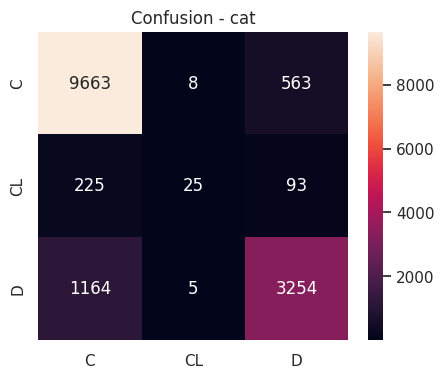

Class C logloss: 0.19467297291644467
Class CL logloss: 2.684288625790147
Class D logloss: 0.5740861151119176

=== Model: stack
              precision    recall  f1-score   support

           C       0.88      0.94      0.91     10234
          CL       0.57      0.17      0.26       343
           D       0.83      0.74      0.78      4423

    accuracy                           0.86     15000
   macro avg       0.76      0.62      0.65     15000
weighted avg       0.86      0.86      0.86     15000



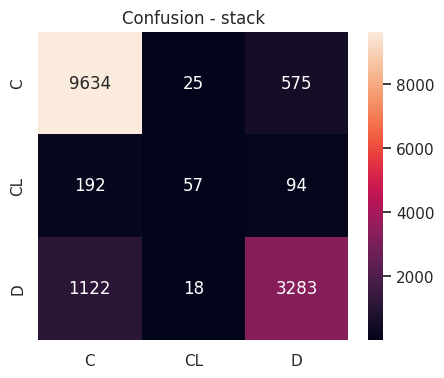

Class C logloss: 0.1995547754004395
Class CL logloss: 2.746507706278688
Class D logloss: 0.5893140169072608

=== Model: blend
              precision    recall  f1-score   support

           C       0.87      0.95      0.91     10234
          CL       0.89      0.05      0.09       343
           D       0.83      0.74      0.78      4423

    accuracy                           0.86     15000
   macro avg       0.87      0.58      0.59     15000
weighted avg       0.86      0.86      0.85     15000



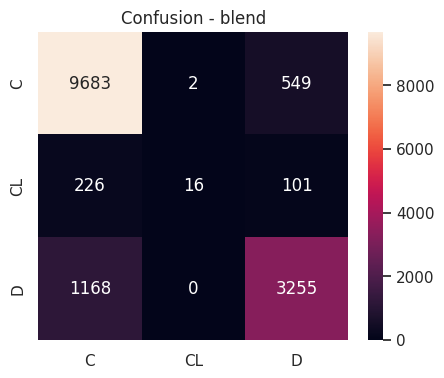

Class C logloss: 0.2071296547606062
Class CL logloss: 2.498220480404911
Class D logloss: 0.5851153308166641



In [ ]:
# Cell 15: OOF evaluation (choose best ensembles to inspect)
def per_class_logloss_manual(y_true_idx, pred_probs, class_index):
    mask = (y_true_idx == class_index)
    if mask.sum() == 0: return np.nan
    probs = pred_probs[mask, class_index]
    probs = np.clip(probs, 1e-15, 1-1e-15)
    return -np.mean(np.log(probs))

# show for best single, stack, blend
display_models = [best_name, "stack", "blend"]
for name in display_models:
    print("=== Model:", name)
    if name in ensemble_oofs:
        oof = ensemble_oofs[name]
    else:
        oof = oof_preds[name]
    preds = np.argmax(oof, axis=1)
    print(classification_report([idx_to_label[i] for i in y], [idx_to_label[i] for i in preds]))
    # Confusion
    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(5,4)); sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels); plt.title(f"Confusion - {name}"); plt.show()
    # Per-class logloss
    for i in range(n_classes):
        print("Class", idx_to_label[i], "logloss:", per_class_logloss_manual(y, oof, i))
    print("")


Stack ROC:


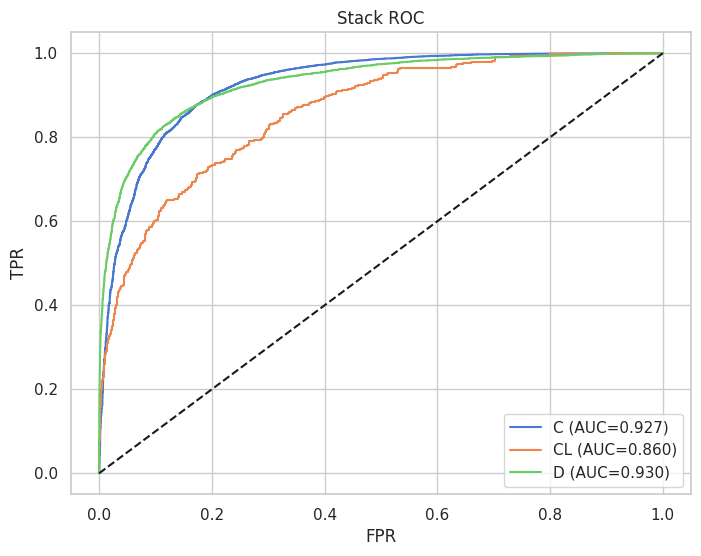

Macro AUC: 0.9056880775125098
Blend ROC:


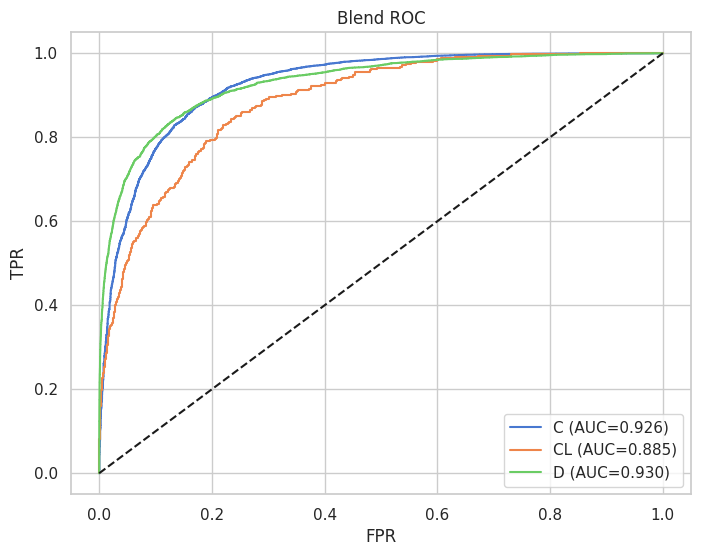

Macro AUC: 0.9133983509904255


In [ ]:
# Cell 16: ROC (One-vs-Rest) plots for stack and blend
from sklearn.preprocessing import label_binarize
y_bin = label_binarize(y, classes=list(range(n_classes)))

def plot_multiclass_roc(probas, title="ROC"):
    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probas[:, i])
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{idx_to_label[i]} (AUC={auc_score:.3f})")
    plt.plot([0,1],[0,1],"k--"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(title); plt.legend(); plt.show()
    print("Macro AUC:", roc_auc_score(y_bin, probas, average="macro", multi_class="ovr"))

print("Stack ROC:"); plot_multiclass_roc(ensemble_oofs["stack"], "Stack ROC")
print("Blend ROC:"); plot_multiclass_roc(ensemble_oofs["blend"], "Blend ROC")


In [ ]:
# Cell 17: Temperature scaling function (optimize temperature on validation predictions to reduce logloss)
def temperature_scale(probs, y_true):
    """
    probs: (n_samples, n_classes) uncalibrated probabilities
    y_true: (n_samples,) integer labels
    returns optimal temperature scalar and calibrated probs
    """
    # negative log likelihood given temperature t:
    def nll(t):
        t = t[0]
        scaled = np.log(probs + 1e-15) / t
        scaled = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
        scaled = scaled / np.sum(scaled, axis=1, keepdims=True)
        return log_loss(y_true, scaled)

    init = np.array([1.0])
    bounds = [(0.05, 5.0)]
    res = minimize(nll, init, bounds=bounds, method="L-BFGS-B")
    t_opt = float(res.x[0])
    # compute calibrated probs
    scaled = np.log(probs + 1e-15) / t_opt
    scaled = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
    scaled = scaled / np.sum(scaled, axis=1, keepdims=True)
    return t_opt, scaled

# Fit temperature on OOF blend (use blend OOF as it's top)
print("Fitting temperature on blend OOF...")
t_opt, calibrated_blend_oof = temperature_scale(ensemble_oofs["blend"], y)
print("Optimal temperature:", t_opt)
print("Blend OOF logloss before:", log_loss(y, ensemble_oofs["blend"]), "after:", log_loss(y, calibrated_blend_oof))


Fitting temperature on blend OOF...
Optimal temperature: 0.8447981282744571
Blend OOF logloss before: 0.3709746414902075 after: 0.3642199684220814


In [ ]:
# Cell 18: Retrain final selected models on full training data and predict test set
# We'll produce three test prob sets: best single, stack, blend; then average and apply temperature scaling.

# 1) retrain best single
print("Retraining best single:", best_name)
models[best_name].fit(X_all, y)
probs_best_test = models[best_name].predict_proba(X_test)

# 2) retrain top5 for stack final
estimators = [(nm, models[nm]) for nm in top5]
stack_final = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(multi_class="multinomial", max_iter=2000), n_jobs=-1, passthrough=False)
print("Fitting final stack (this may take time)...")
stack_final.fit(X_all, y)
probs_stack_test = stack_final.predict_proba(X_test)

# 3) final blend: weighted average using same weights computed earlier; retrain base models on full
for nm in top5:
    try:
        models[nm].fit(X_all, y)
    except Exception as e:
        print("Retrain err for", nm, e)
probs_blend_test = np.zeros((len(test), n_classes))
for w, nm in zip(weights, top5):
    probs_blend_test += models[nm].predict_proba(X_test) * w

# 4) average ensemble
final_probs_raw = (probs_best_test + probs_stack_test + probs_blend_test) / 3.0
print("Raw final probs check row sums (first 5):", final_probs_raw[:5].sum(axis=1))


Retraining best single: cat
Fitting final stack (this may take time)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5431
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 46
[LightGBM] [Info] Start training from score -0.382359
[LightGBM] [Info] Start training from score -3.775891
[LightGBM] [Info] Start training from score -1.221345
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018655 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5435
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 46
[LightGBM] [Info] Start training from score -0.382237
[LightGBM] [Info] Start training from score -3.779534
[LightGBM] [Info] Start training from score -1.221345
[LightGBM] [Info] Auto-cho

In [ ]:
# Cell 19: Apply temperature scaling to final_probs_raw using t_opt found earlier on OOF
def apply_temperature_to_probs(probs, temperature):
    scaled = np.log(probs + 1e-15) / temperature
    scaled = np.exp(scaled - np.max(scaled, axis=1, keepdims=True))
    scaled = scaled / np.sum(scaled, axis=1, keepdims=True)
    return scaled

final_probs_calibrated = apply_temperature_to_probs(final_probs_raw, t_opt)
print("Calibrated final probs row-sum (first5):", final_probs_calibrated[:5].sum(axis=1))

# Map columns to Status_C, Status_CL, Status_D
output_cols = ["Status_C", "Status_CL", "Status_D"]
# final_probs columns correspond to label indices according to idx_to_label
col_map = [f"Status_{idx_to_label[i]}" for i in range(n_classes)]
print("Inferred col_map:", col_map)

# reorder final_probs_calibrated columns to match output_cols order
reordered = np.zeros((final_probs_calibrated.shape[0], len(output_cols)))
for i in range(n_classes):
    colname = f"Status_{idx_to_label[i]}"
    pos = output_cols.index(colname)
    reordered[:, pos] = final_probs_calibrated[:, i]

submission = pd.DataFrame(reordered, columns=output_cols)
submission.insert(0, ID_COL, test[ID_COL].values if ID_COL in test.columns else test.index)
out_name = "submission_top1_ensemble.csv"
submission.to_csv(out_name, index=False)
print("Saved submission to", out_name)
display(submission.head())


Calibrated final probs row-sum (first5): [1. 1. 1. 1. 1.]
Inferred col_map: ['Status_C', 'Status_CL', 'Status_D']
Saved submission to submission_top1_ensemble.csv


,id,Status_C,Status_CL,Status_D
0,15000,0.932507,0.008338,0.059155
1,15001,0.966580,0.002940,0.030481
2,15002,0.784211,0.024610,0.191179
3,15003,0.036746,0.008381,0.954874
4,15004,0.977682,0.002361,0.019957
